In [6]:
import torch
import torch.nn as nn

from mslandcover.models import DeepLabV3Plus, ResNetBackbone, UNet, ResNetBackboneUNet, AttentionUNet, BYOLWrapper
from mslandcover.utils import load_pth
import rasterio as rio
from glob import iglob, glob
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt


In [2]:


test_images = glob('/scratch/dhester/mslc_data_v2/pretrain_val/*.tif')
# select first 32 test images
# randomly sample 1024 test images
# test_images = [next(test_images) for _ in range(8192)]


x_batch = torch.stack([torch.from_numpy(rio.open(img).read([4, 1, 2])).float() / 255.0 for img in test_images])

mean = torch.load('./weights/pretrain_mean.pth')
std = torch.load('./weights/pretrain_std.pth')

x_batch = (x_batch - mean[None, :, None, None]) / std[None, :, None, None]

/tmp/ipykernel_38776/416455113.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean = torch.load('./weights/pretrain_mean.pth')
/tmp/ipykernel_38776/416455113.py:10: Fut

In [ ]:


backbone = ResNetBackboneUNet(in_channels=3, pretrained=False)

x = torch.randn(2, 3, 256, 256)
backbone.eval()
with torch.no_grad():
    features = backbone(x)

In [4]:
for feature in features:
    print(feature.shape)

torch.Size([2, 64, 128, 128])
torch.Size([2, 256, 64, 64])
torch.Size([2, 512, 32, 32])
torch.Size([2, 1024, 16, 16])
torch.Size([2, 2048, 8, 8])


In [27]:



# weights_1 = torch.load('weights/resnet101_202506/byol_bands3_size256_randinitfalse/resnet101/byol.pth', map_location='cpu')
# weights_2 = torch.load('weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
byol_weights = torch.load('weights/resnet101_20250624/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
byol_collapsed_weights = torch.load('weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
finetuned_weights = torch.load('./weights/finetuned_unet/best_model.pth')

/tmp/ipykernel_38776/2470336702.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  byol_weights = torch.load('weights/resnet101_20250624/byol_bands3_size256_randinitfalse/r

In [29]:
from tqdm import trange
batch_size = 256

model = models.resnet101(weights=None)
model.fc = nn.Identity()  # Remove the final classification layer
model.eval()
model = model.to('cuda')

h_random = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_random.append(h_part)
h_random = np.concatenate(h_random, axis=0)

model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
model.fc = nn.Identity()  # Remove the final classification layer
model.eval()
model = model.to('cuda')

h_inet = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_inet.append(h_part)
h_inet = np.concatenate(h_inet, axis=0)

byol_collapsed_weights_adj = {}
for key in list(byol_collapsed_weights.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        byol_collapsed_weights_adj[new_key] = byol_collapsed_weights[key]
model.load_state_dict(byol_collapsed_weights_adj, strict=True)

h_byol_collapsed = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_byol_collapsed.append(h_part)
h_byol_collapsed = np.concatenate(h_byol_collapsed, axis=0)

byol_weights_adj = {}
for key in list(byol_weights.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        byol_weights_adj[new_key] = byol_weights[key]
model.load_state_dict(byol_weights_adj, strict=True)

h_byol = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_byol.append(h_part)
# h_byol = torch.cat(h_byol, dim=0)
h_byol = np.concatenate(h_byol, axis=0)

100%|██████████| 370/370 [01:08<00:00,  5.38it/s]


In [17]:

finetuned_weights_adj = {}
for key in list(finetuned_weights.keys()):
    if key.startswith('backbone.'):
        new_key = key.replace('backbone.', '')
        
        if new_key.startswith('initial.0'):
            new_key = new_key.replace('initial.0', 'conv1')
        elif new_key.startswith('initial.1'):
            new_key = new_key.replace('initial.1', 'bn1')
        
        finetuned_weights_adj[new_key] = finetuned_weights[key]
model.load_state_dict(finetuned_weights_adj, strict=True)

h_finetuned = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_finetuned.append(h_part)
# h_finetuned = torch.cat(h_finetuned, dim=0)
h_finetuned = np.concatenate(h_finetuned, axis=0)

  0%|          | 0/370 [00:00<?, ?it/s]

100%|██████████| 370/370 [01:08<00:00,  5.39it/s]


In [ ]:
import os
os.makedirs('./val_embeddings', exist_ok=True)

np.save('./val_embeddings/h_random.npy', h_random)
np.save('./val_embeddings/h_inet.npy', h_inet)
np.save('./val_embeddings/h_byol_collapsed.npy', h_byol_collapsed)
np.save('./val_embeddings/h_byol.npy', h_byol)
np.save('./val_embeddings/h_finetuned.npy', h_finetuned)

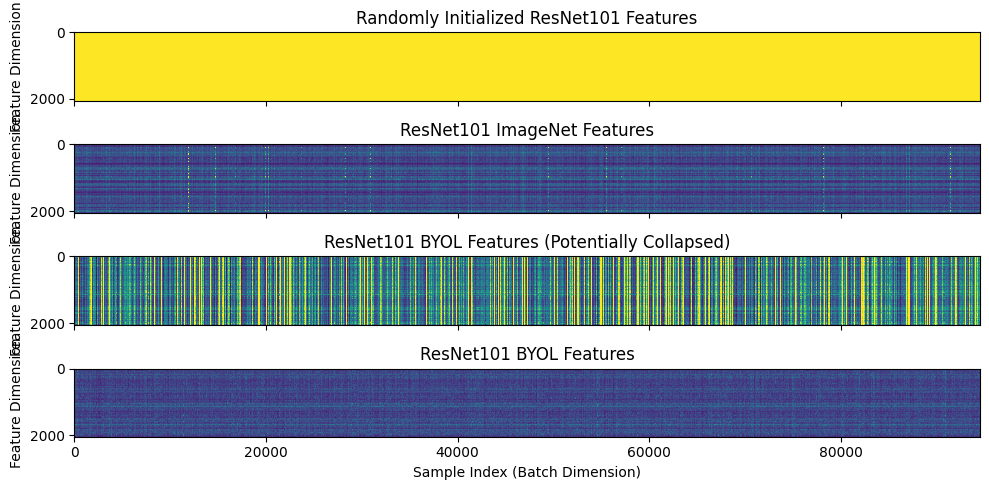

In [30]:
fig, ax = plt.subplots(4, 1, figsize=(10, 5), sharex=True)


ax[0].imshow(h_random.T, vmin=0, vmax=0.5)
ax[0].set_title('Randomly Initialized ResNet101 Features')
ax[0].set_ylabel('Feature Dimension')

ax[1].imshow(h_inet.T, vmin=0, vmax=0.5)
ax[1].set_title('ResNet101 ImageNet Features')
ax[1].set_ylabel('Feature Dimension')

ax[2].imshow(h_byol_collapsed.T, vmin=0, vmax=0.5)
ax[2].set_title('ResNet101 BYOL Features (Potentially Collapsed)')
ax[2].set_ylabel('Feature Dimension')

ax[3].imshow(h_byol.T, vmin=0, vmax=0.5)
ax[3].set_title('ResNet101 BYOL Features')
ax[3].set_ylabel('Feature Dimension')

ax[3].set_xlabel('Sample Index (Batch Dimension)')

for a in ax:
    a.set_aspect('auto')

fig.tight_layout()
plt.show()

In [34]:
# shape (N, M) # where N is the number of samples (batch dimension) and M is the feature dimension

print(f'H_random std: {h_random.std(axis=1).mean()}')
print(f'H_inet std: {h_inet.std(axis=1).mean()}')
print(f'H_byol_collapsed std: {h_byol_collapsed.std(axis=1).mean()}')
print(f'H_byol std: {h_byol.std(axis=1).mean()}')

H_random std: 26058.79296875
H_inet std: 0.3658319413661957
H_byol_collapsed std: 0.44455623626708984
H_byol std: 0.3590213656425476


In [ ]:
# view principal components of features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.ravel()

# feature_models = ['ImageNet', 'BYOL (weights_1)', 'BYOL (weights_2)', 'BYOL (weights_3)']
# feature_models = ['Random Initialization', 'ImageNet', 'BYOL', 'Finetuned']
feature_models = ['Random Initialization', 'ImageNet', 'BYOL (Potentially Collapsed)', 'BYOL']

# for i, embeddings in enumerate([h_random, h_inet, h_byol, h_finetuned]):
for i, embeddings in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    # Flatten the embeddings
    # flattened_embeddings = embeddings.view(embeddings.size(0), -1).detach().numpy()
    
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=2)
    )
    pca_embeddings = pipe.fit_transform(embeddings)
    
    # Plot the PCA results
    ax[i].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], alpha=0.5)
    ax[i].set_title(f'PCA of Features from {feature_models[i]}')
    ax[i].set_xlabel(f'Principal Component 1 ({pipe['pca'].explained_variance_ratio_[0]:.2%})')
    ax[i].set_ylabel(f'Principal Component 2 ({pipe['pca'].explained_variance_ratio_[1]:.2%})')

fig.tight_layout()
plt.show()

In [ ]:
print(f'H_inet std: {h_inet.std(axis=0).mean()}')
print(f'H_1 std: {h_1.std(axis=1).mean()}')
print(f'H_2 std: {h_2.std(axis=1).mean()}')
print(f'H_3 std: {h_3.std(axis=1).mean()}')

H_inet std: 0.3658319413661957


NameError: name 'h_1' is not defined

In [168]:
print(h_inet.std(axis=0).shape) # standard deviation of features across samples
# print(h_inet.std(axis=1).shape) # standard deviation of samples across features

(2048,)


UMAP( verbose=True)
Fri Jun 27 21:19:26 2025 Construct fuzzy simplicial set
Fri Jun 27 21:19:26 2025 Finding Nearest Neighbors
Fri Jun 27 21:19:26 2025 Building RP forest with 10 trees
Fri Jun 27 21:19:26 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Fri Jun 27 21:19:28 2025 Finished Nearest Neighbor Search
Fri Jun 27 21:19:28 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Jun 27 21:19:45 2025 Finished embedding
UMAP( verbose=True)
Fri Jun 27 21:19:45 2025 Construct fuzzy simplicial set
Fri Jun 27 21:19:45 2025 Finding Nearest Neighbors
Fri Jun 27 21:19:45 2025 Building RP forest with 10 trees
Fri Jun 27 21:19:45 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Fri Jun 27 21:19:46 2025 Finished Nearest Neighbor Search
Fri Jun 27 21:19:46 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Jun 27 21:20:01 2025 Finished embedding
UMAP( verbose=True)
Fri Jun 27 21:20:01 2025 Construct fuzzy simplicial set
Fri Jun 27 21:20:01 2025 Finding Nearest Neighbors
Fri Jun 27 21:20:01 2025 Building RP forest with 10 trees
Fri Jun 27 21:20:01 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Fri Jun 27 21:20:02 2025 Finished Nearest Neighbor Search
Fri Jun 27 21:20:02 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Jun 27 21:20:17 2025 Finished embedding
UMAP( verbose=True)
Fri Jun 27 21:20:17 2025 Construct fuzzy simplicial set
Fri Jun 27 21:20:17 2025 Finding Nearest Neighbors
Fri Jun 27 21:20:17 2025 Building RP forest with 10 trees
Fri Jun 27 21:20:18 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Fri Jun 27 21:20:19 2025 Finished Nearest Neighbor Search
Fri Jun 27 21:20:19 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Jun 27 21:20:34 2025 Finished embedding


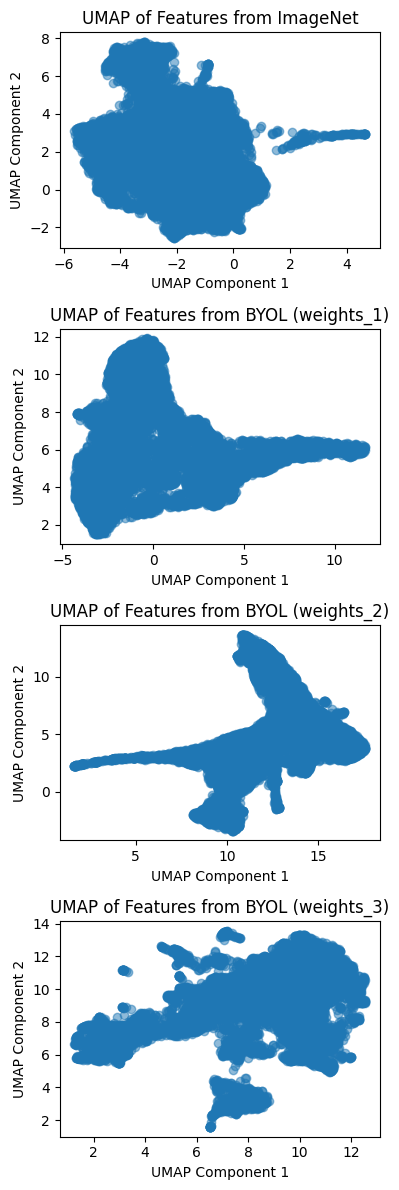

In [ ]:
# apply umap 
from umap import UMAP



fig, ax = plt.subplots(4, 1, figsize=(4, 12))
for i, umap_embeddings in enumerate([h_inet, h_1, h_2, h_3]):
    
    model = UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='euclidean',
        # random_state=42,
        verbose=True,
        n_jobs=-1
    )
    
    umap_embeddings = model.fit_transform(umap_embeddings)
    
    ax[i].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], alpha=0.5)
    ax[i].set_title(f'UMAP of Features from {feature_models[i]}')
    ax[i].set_xlabel('UMAP Component 1')
    ax[i].set_ylabel('UMAP Component 2')

fig.tight_layout()
plt.show()

In [158]:
from sklearn.preprocessing import normalize

def analyze_embeddings(X):
    # X = X - X.mean(axis=0)
    X = normalize(X, axis=0)  # Normalize features to unit norm
    cov = np.cov(X, rowvar=False)  # shape (d, d)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, a_min=1e-10, a_max=None)  # avoid divide-by-zero

    pr = (np.sum(eigvals) ** 2) / np.sum(eigvals ** 2)
    isotropy = eigvals.min() / eigvals.max()
    condition_number = eigvals.max() / eigvals.min()

    return {
        "eigvals": eigvals,
        "participation_ratio": pr,
        "isotropy_index": isotropy,
        "condition_number": condition_number
    }
    
for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
    analysis = analyze_embeddings(embeddings)
    print(f"Analysis for {feature_models[i]}:")
    print(f"  Participation Ratio: {analysis['participation_ratio']:.4f}")
    print(f"  Isotropy Index: {analysis['isotropy_index']:.4f}")
    print(f"  Condition Number: {analysis['condition_number']:.4f}")
    print(f"  Eigenvalues: {analysis['eigvals'][:10]}...")  # Show first 10 eigenvalues
    print()

Analysis for ImageNet:
  Participation Ratio: 47.0354
  Isotropy Index: 0.0000
  Condition Number: 803584.8651
  Eigenvalues: [2.69278028e-09 3.58016993e-09 4.47281249e-09 5.20273242e-09
 6.69738076e-09 7.91333839e-09 9.81616323e-09 1.01497390e-08
 1.41169982e-08 1.58495252e-08]...

Analysis for BYOL (weights_1):
  Participation Ratio: 18.1302
  Isotropy Index: 0.0000
  Condition Number: 59933.5366
  Eigenvalues: [5.06745341e-08 5.40657744e-08 7.30842140e-08 7.71857023e-08
 7.99576898e-08 8.12072178e-08 8.24444830e-08 8.35450697e-08
 9.07732131e-08 9.32795173e-08]...

Analysis for BYOL (weights_2):
  Participation Ratio: 2.2503
  Isotropy Index: 0.0000
  Condition Number: 7294771.2866
  Eigenvalues: [1.70499718e-09 1.95465190e-09 2.04695143e-09 2.49142602e-09
 2.64289498e-09 3.01737378e-09 3.20821480e-09 3.59570717e-09
 3.67032859e-09 4.06265403e-09]...

Analysis for BYOL (weights_3):
  Participation Ratio: 98.1826
  Isotropy Index: 0.0000
  Condition Number: 238139.2656
  Eigenvalues:

Plotting cosine similarity histogram for Random Initialization...
Mean Cosine Similarity: 0.9995
Std Dev: 0.0006
Plotting cosine similarity histogram for ImageNet...
Mean Cosine Similarity: 0.4627
Std Dev: 0.1635
Plotting cosine similarity histogram for BYOL (Potentially Collapsed)...
Mean Cosine Similarity: 0.2724
Std Dev: 0.2621
Plotting cosine similarity histogram for BYOL...
Mean Cosine Similarity: 0.1647
Std Dev: 0.1420


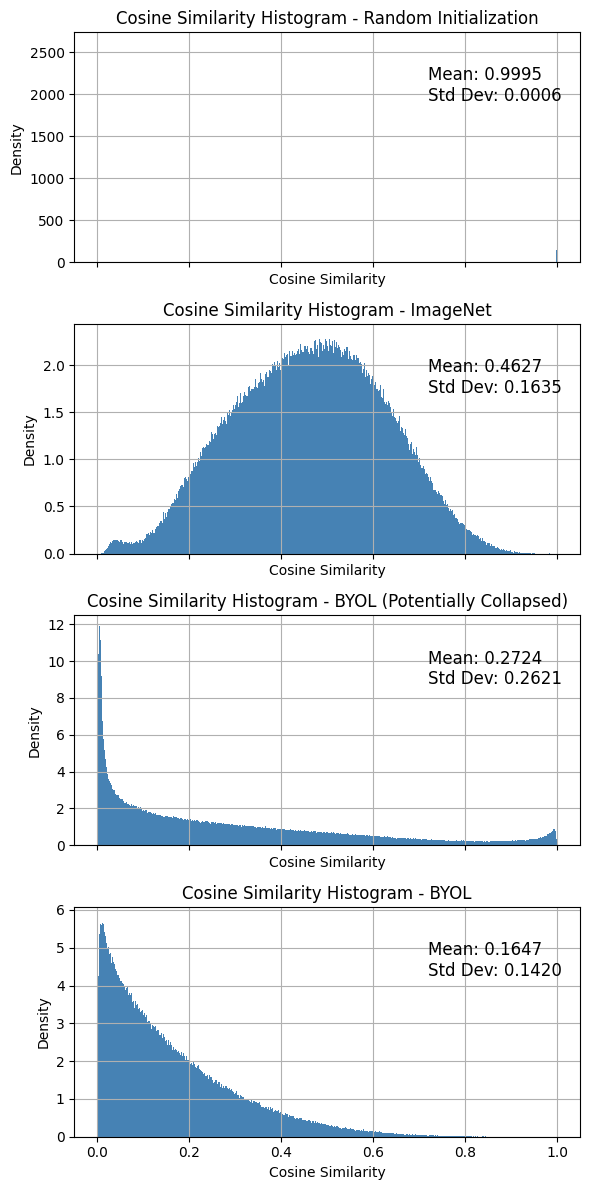

In [37]:
from sklearn.preprocessing import normalize

def plot_cosine_histogram(X, num_samples=100000, bins=100, ax=None):
    """
    X: (N, d) numpy array of embeddings
    num_samples: number of random pairs to sample
    bins: histogram resolution
    """

    # Normalize embeddings to unit vectors
    X_norm = normalize(X, axis=1)

    N = X.shape[0]
    sim_scores = []

    # Sample random pairs
    for _ in range(num_samples):
        i, j = np.random.randint(0, N, size=2)
        sim = np.dot(X_norm[i], X_norm[j])
        sim_scores.append(sim)

    sim_scores = np.array(sim_scores)

    # Plot
    if ax is None:
        ax = plt.subplots(figsize=(8, 6))
        
    ax.hist(sim_scores, bins=bins, density=True, color='steelblue')
    # ax.suptitle("Histogram of Cosine Similarities Between Embeddings")
    # ax.subtitle("Cosine Similarity Histogram")
    # ax.set_title("Cosine Similarity Histogram")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Density")
    ax.grid(True)
    
    ax.text(0.7, 0.7, f"Mean: {sim_scores.mean():.4f}\nStd Dev: {sim_scores.std():.4f}",
            transform=ax.transAxes, fontsize=12)
    fig.tight_layout()
    fig.show()

    # Summary statistics
    print(f"Mean Cosine Similarity: {sim_scores.mean():.4f}")
    print(f"Std Dev: {sim_scores.std():.4f}")


fig, ax = plt.subplots(4, 1, figsize=(6, 12), sharex=True)
# for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
for i, embeddings in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    print(f"Plotting cosine similarity histogram for {feature_models[i]}...")
    plot_cosine_histogram(embeddings, num_samples=1000000, bins=1000, ax=ax[i])
    ax[i].set_title(f"Cosine Similarity Histogram - {feature_models[i]}")
    # print()
    # print(f"Mean Cosine Similarity: {embeddings.detach().numpy().mean():.4f}")
    # print(f"Std Dev: {embeddings.detach().numpy().std():.4f}")
    # print(f"Max Cosine Similarity: {embeddings.detach().numpy().max():.4f}")
    # print(f"Min Cosine Similarity: {embeddings.detach().numpy().min():.4f}")
    # print(f"Shape: {embeddings.shape}")
    # print(f"Mean: {embeddings.mean():.4f}")
    # print(f"Std: {embeddings.std():.4f}")

In [38]:
from scipy.spatial.distance import pdist

def plot_distance_histogram(X, metric='euclidean', num_samples=100000, bins=100, ax=None):
    
    X_norm = normalize(X, axis=1)  # Normalize embeddings to unit vectors
    """
    X: (N, d) numpy array of embeddings
    metric: distance metric to use
    num_samples: number of random pairs to sample
    bins: histogram resolution
    """
    
    # Compute pairwise distances
    distances = pdist(X_norm, metric=metric)
    
    # Sample random distances if needed
    if len(distances) > num_samples:
        distances = np.random.choice(distances, size=num_samples, replace=False)
    
    # # Plot histogram
    # plt.figure(figsize=(8, 6))
    # plt.hist(distances, bins=bins, density=True, color='steelblue', edgecolor='black')
    # plt.title(f"Histogram of {metric.capitalize()} Distances Between Embeddings")
    # plt.xlabel(f"{metric.capitalize()} Distance")
    # plt.ylabel("Density")
    # plt.grid(True)
    
    # plt.text(0.8, 0.8, f"Mean: {distances.mean():.4f}\nStd Dev: {distances.std():.4f}",
    #          transform=plt.gca().transAxes, fontsize=12)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(distances, bins=bins, density=True, color='steelblue', edgecolor='black')
    ax.set_title(f"Histogram of {metric.capitalize()} Distances Between Embeddings")
    ax.set_xlabel(f"{metric.capitalize()} Distance")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.text(0.8, 0.8, f"Mean: {distances.mean():.4f}\nStd Dev: {distances.std():.4f}",
            transform=ax.transAxes, fontsize=12)
    
    # plt.tight_layout()
    # plt.show()
# distances = pdist(X, metric='euclidean')
# plt.hist(distances, bins=100)

for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
    print(f"Plotting distance histogram for {feature_models[i]}...")
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_distance_histogram(embeddings.detach().numpy(), metric='euclidean', num_samples=10000, bins=100, ax=ax)
    ax.set_title(f"Distance Histogram - {feature_models[i]}")
    print()
    print(f"Mean Distance: {embeddings.detach().numpy().mean():.4f}")
    print(f"Std Dev: {embeddings.detach().numpy().std():.4f}")
    print(f"Max Distance: {embeddings.detach().numpy().max():.4f}")
    print(f"Min Distance: {embeddings.detach().numpy().min():.4f}")
    print(f"Shape: {embeddings.shape}")
    print(f"Mean: {embeddings.mean():.4f}")
    print(f"Std: {embeddings.std():.4f}")

NameError: name 'h_1' is not defined